# P1 · 03 — Exponential smoothing: SES → Holt → Holt-Winters

Exponential smoothing forecasts are **weighted averages of past observations,
with weights decaying exponentially into the past** — recent data matters most.
The family grows by adding components:

| model | components | good for |
|-------|-----------|----------|
| **SES** | level only | flat, no-trend series |
| **Holt** | level + trend | trending series (no seasonality) |
| **Holt-Winters** | level + trend + seasonal | trending *and* seasonal series |

We fit on **log(GDP)** throughout (so multiplicative growth/seasonality become
additive). Every model is also run through the **same backtest** as the baselines.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from src import baselines as B, backtest as bt, classical as C

annual = data.load_annual()
q = data.load_quarterly()
la = np.log(annual)              # log annual real GDP (trend, no seasonality)
nsa = q["gdp_nsa"]               # quarterly NSA (trend + seasonality)

### SES — level only (and why it fails on GDP)

SES tracks a single smoothed **level** $\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}$
and forecasts it **flat** into the future. For a trending series like GDP that's
obviously wrong — but seeing it fail builds intuition for what Holt adds.

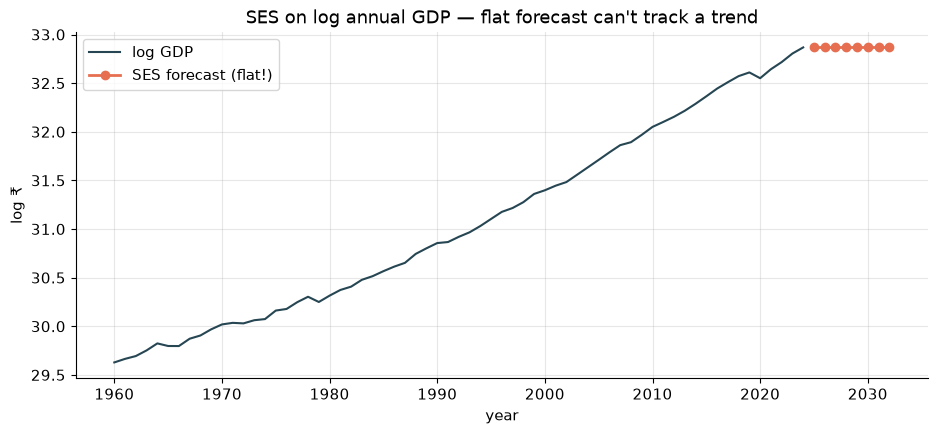

smoothing level alpha = 1.000


In [2]:
H = 8
ses = SimpleExpSmoothing(la.values, initialization_method="estimated").fit()
fc = ses.forecast(H)
yrs = np.arange(annual.index.max() + 1, annual.index.max() + 1 + H)
fig, ax = plt.subplots()
ax.plot(annual.index, la.values, color="#264653", label="log GDP")
ax.plot(yrs, fc, color="#e76f51", lw=2, marker="o", label="SES forecast (flat!)")
ax.set(title="SES on log annual GDP — flat forecast can't track a trend",
       xlabel="year", ylabel="log ₹"); ax.legend(); plt.show()
print(f"smoothing level alpha = {ses.params['smoothing_level']:.3f}")

### Holt — add a trend component

Holt adds a **trend** $b_t$ that's also exponentially smoothed, so the forecast
extrapolates the recent slope: $\hat y_{t+h} = \ell_t + h\,b_t$. Now the forecast
climbs with the series.

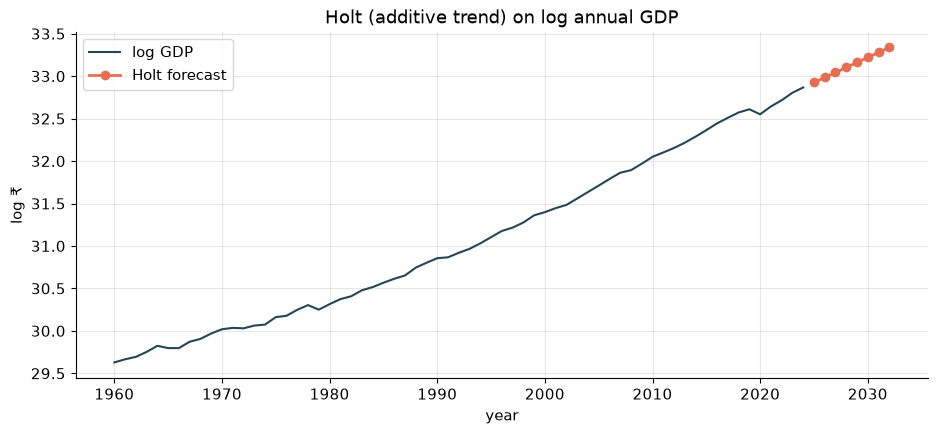

alpha=0.908, beta(trend)=0.079


In [3]:
holt = ExponentialSmoothing(la.values, trend="add",
                            initialization_method="estimated").fit()
fc = holt.forecast(H)
fig, ax = plt.subplots()
ax.plot(annual.index, la.values, color="#264653", label="log GDP")
ax.plot(yrs, fc, color="#e76f51", lw=2, marker="o", label="Holt forecast")
ax.set(title="Holt (additive trend) on log annual GDP",
       xlabel="year", ylabel="log ₹"); ax.legend(); plt.show()
print(f"alpha={holt.params['smoothing_level']:.3f}, "
      f"beta(trend)={holt.params['smoothing_trend']:.3f}")

### Holt-Winters — add a seasonal component (quarterly)

For the quarterly series we add a **seasonal** term with period 4. Because we fit
on the log, we use *additive* seasonality (additive-on-log = multiplicative on the
original scale — the right choice for GDP). The forecast now has the familiar
saw-tooth restored.

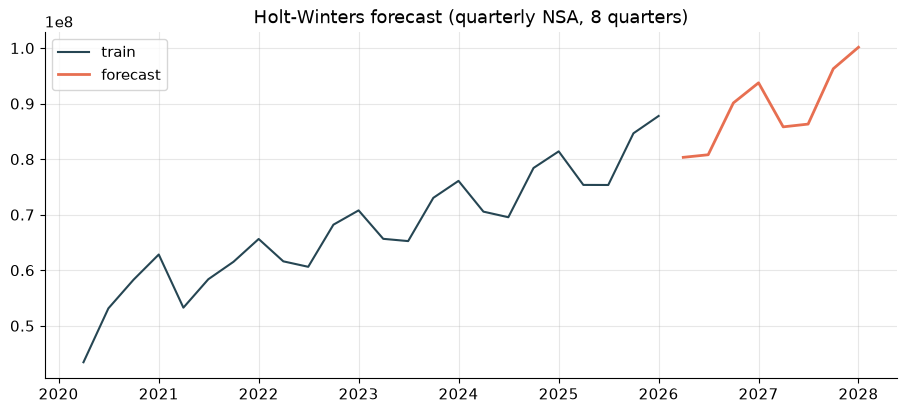

Forecast (₹, levels):
2026Q2     80321317.0
2026Q3     80787431.0
2026Q4     90114067.0
2027Q1     93736523.0
2027Q2     85809585.0
2027Q3     86307548.0
2027Q4     96271463.0
2028Q1    100141438.0
Freq: Q-DEC, dtype: float64


In [4]:
hw = ExponentialSmoothing(np.log(nsa).values, trend="add", seasonal="add",
                          seasonal_periods=4,
                          initialization_method="estimated").fit()
fc_log = hw.forecast(H)
future = pd.period_range(nsa.index.max() + 1, periods=H, freq="Q")
fc = pd.Series(np.exp(fc_log), index=future)

fig, ax = plt.subplots()
plots.plot_forecast(nsa.iloc[-24:], pred=fc,
                    title="Holt-Winters forecast (quarterly NSA, 8 quarters)", ax=ax)
plt.show()
print("Forecast (₹, levels):")
print(fc.round(0))

### Does it actually beat the baselines? (the only question that matters)

We backtest Holt, Holt-Winters, and a **damped** variant (damping shrinks the
trend over the horizon, guarding against runaway extrapolation) against the
baselines — same rolling-origin folds as notebook 02.

In [5]:
fcs = {
    "seasonal_naive(4)": B.seasonal_naive(4),
    "drift": B.drift,
    "Holt (no seasonal)": C.ets_forecaster(trend="add", seasonal=None),
    "Holt-Winters": C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4),
    "Holt-Winters (damped)": C.ets_forecaster(trend="add", seasonal="add",
                                              seasonal_periods=4, damped_trend=True),
}
bt.compare(nsa, fcs, initial=40, h=4, step=1, season_length=4).round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
Holt-Winters (damped),2093500.037,3453072.867,3.675,3.607,0.639
Holt-Winters,2097819.195,3929438.519,3.809,3.771,0.640
Holt (no seasonal),2923125.011,4370184.963,5.016,4.849,0.892
drift,3322822.364,4827551.462,5.627,5.591,1.014
seasonal_naive(4),4138715.808,4655608.591,7.221,7.392,1.263


Holt-Winters should land around **MASE ≈ 0.64** — a ~36% improvement over the
naive benchmark, and far ahead of the non-seasonal Holt (which ignores the strong
seasonality we measured in notebook 01). Lesson: **match model components to the
structure you diagnosed.** No seasonality term → no chance against a seasonal series.

> ETS as a *family*: statsmodels' `ETSModel` formalises Error-Trend-Seasonal
> combinations (additive/multiplicative × each component) and can auto-select by
> AIC — the same idea as auto-ARIMA, for the smoothing family.

---
**Next (04):** ARIMA/SARIMA — the other classical pillar — and a head-to-head.